In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import seaborn as sns

In [2]:
order_items_mart = pd.read_csv("../data/processed/order_items_mart.csv")

In [3]:
order_items_mart["order_purchase_timestamp"] = pd.to_datetime(order_items_mart["order_purchase_timestamp"])
order_items_mart["order_month_date"] = (order_items_mart["order_purchase_timestamp"].dt.to_period("M").dt.to_timestamp())

Считаем, какие категории приносят основную долю выручки. Построим накопительную долю выручки, чтобы увидеть, сколько категорий дают 80% дохода маркетплейса.

In [4]:
category_revenue = (order_items_mart.groupby("product_category_name_english", as_index=False).agg(revenue=("item_total", "sum")).sort_values("revenue", ascending=False))
category_revenue["revenue_share"] = category_revenue["revenue"] / category_revenue["revenue"].sum()
category_revenue["cumulative_share"] = category_revenue["revenue_share"].cumsum()
category_revenue.head(15)

,product_category_name_english,revenue,revenue_share,cumulative_share
44,health_beauty,1441248.07,0.090967,0.090967
71,watches_gifts,1305541.61,0.082402,0.173370
8,bed_bath_table,1241681.72,0.078371,0.251741
66,sports_leisure,1156656.48,0.073005,0.324746
16,computers_accessories,1059272.40,0.066858,0.391604
40,furniture_decor,902511.79,0.056964,0.448568
50,housewares,778397.77,0.049130,0.497698
21,cool_stuff,719329.95,0.045402,0.543100
6,auto,685384.32,0.043260,0.586360
43,garden_tools,584219.21,0.036874,0.623234


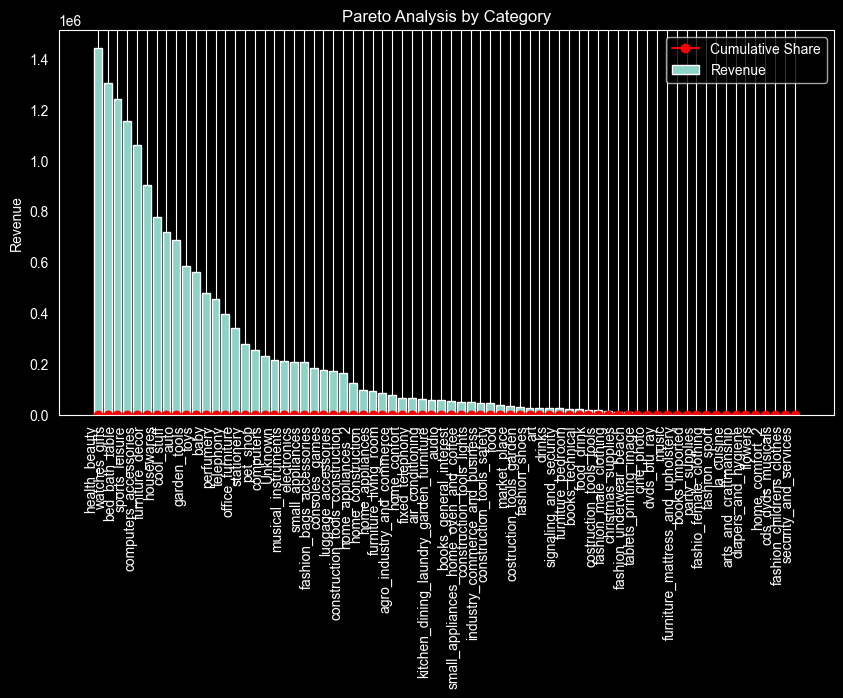

In [5]:
plt.figure(figsize=(10,5))
plt.bar(category_revenue["product_category_name_english"], category_revenue["revenue"], label="Revenue")
plt.plot(category_revenue["product_category_name_english"], category_revenue["cumulative_share"], color="red", marker="o", label="Cumulative Share")
plt.xticks(rotation=90, ha="right")
plt.ylabel("Revenue")
plt.title("Pareto Analysis by Category")
plt.legend()
plt.grid(axis="y")
plt.show()

In [6]:
seller_revenue = (order_items_mart.groupby("seller_id", as_index=False).agg(revenue=("item_total", "sum")).sort_values("revenue", ascending=False).reset_index(drop=True))
seller_revenue["seller_rank"] = seller_revenue.index + 1
seller_revenue["revenue_share"] = seller_revenue["revenue"] / seller_revenue["revenue"].sum()
seller_revenue["cumulative_share"] = seller_revenue["revenue_share"].cumsum()
seller_revenue.head()

,seller_id,revenue,seller_rank,revenue_share,cumulative_share
0,4869f7a5dfa277a7dca6462dcf3b52b2,249640.70,1,0.015757,0.015757
1,7c67e1448b00f6e969d365cea6b010ab,239536.44,2,0.015119,0.030875
2,53243585a1d6dc2643021fd1853d8905,235856.68,3,0.014887,0.045762
3,4a3ca9315b744ce9f8e9374361493884,235539.96,4,0.014867,0.060629
4,fa1c13f2614d7b5c4749cbc52fecda94,204084.73,5,0.012881,0.073510


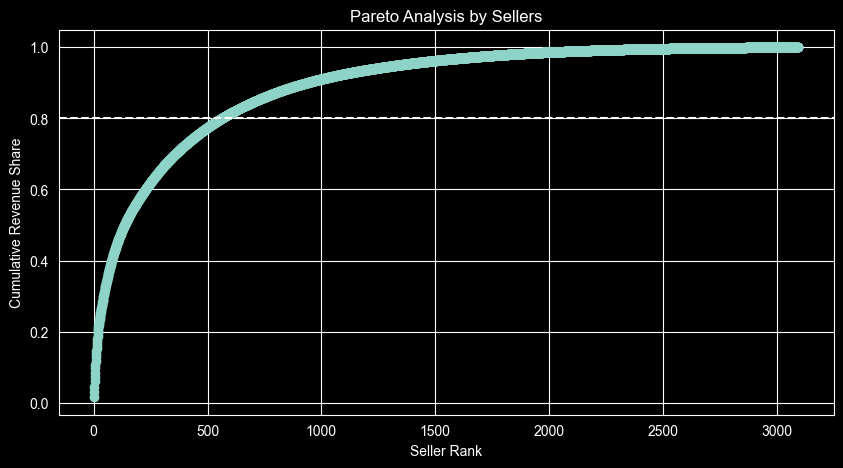

In [7]:
plt.figure(figsize=(10, 5))
plt.plot(seller_revenue["seller_rank"], seller_revenue["cumulative_share"], marker="o")
plt.axhline(0.8, linestyle="--")
plt.title("Pareto Analysis by Sellers")
plt.xlabel("Seller Rank")
plt.ylabel("Cumulative Revenue Share")
plt.grid(True)
plt.show()

In [8]:
sellers_80 = seller_revenue[seller_revenue["cumulative_share"] <= 0.8]["seller_id"].nunique()
sellers_80

561

In [9]:
seller_80_share = sellers_80 / seller_revenue["seller_id"].nunique()
seller_80_share

0.1812600969305331

In [10]:
customer_revenue = (order_items_mart.groupby("customer_unique_id", as_index=False).agg(revenue=("item_total", "sum"), orders_count=("order_id", "nunique")).sort_values("revenue", ascending=False).reset_index(drop=True))
customer_revenue["customer_rank"] = customer_revenue.index + 1
customer_revenue["revenue_share"] = customer_revenue["revenue"] / customer_revenue["revenue"].sum()
customer_revenue["cumulative_share"] = customer_revenue["revenue_share"].cumsum()
customer_revenue.head()

,customer_unique_id,revenue,orders_count,customer_rank,revenue_share,cumulative_share
0,0a0a92112bd4c708ca5fde585afaa872,13664.08,1,1,0.000862,0.000862
1,da122df9eeddfedc1dc1f5349a1a690c,7571.63,2,2,0.000478,0.001340
2,763c8b1c9c68a0229c42c9fc6f662b93,7274.88,1,3,0.000459,0.001800
3,dc4802a71eae9be1dd28f5d788ceb526,6929.31,1,4,0.000437,0.002237
4,459bef486812aa25204be022145caa62,6922.21,1,5,0.000437,0.002674


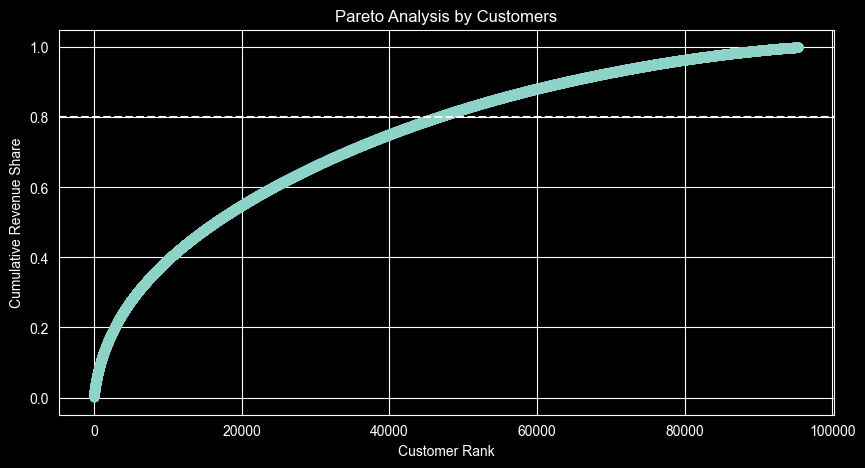

In [11]:
plt.figure(figsize=(10, 5))
plt.plot(customer_revenue["customer_rank"], customer_revenue["cumulative_share"], marker="o")
plt.axhline(0.8, linestyle="--")
plt.title("Pareto Analysis by Customers")
plt.xlabel("Customer Rank")
plt.ylabel("Cumulative Revenue Share")
plt.show()

In [12]:
customers_80 = customer_revenue[customer_revenue["cumulative_share"] <= 0.8]["customer_unique_id"].nunique()
customers_80_share = customers_80 / customer_revenue["customer_unique_id"].nunique()
customers_80, customers_80_share

(46505, 0.4873716202054077)

Pareto-анализ по клиентам показал, что около 46.5 тыс. клиентов, или примерно 48.7% клиентской базы, формируют 80% выручки.
Это означает, что выручка по клиентам распределена относительно широко и не зависит от небольшой группы покупателей.
Такой результат может говорить о высокой доле разовых покупателей и отсутствии сильной концентрации выручки в небольшой группе клиентов.

In [13]:
orders_revenue = (order_items_mart.groupby(["order_id", "main_payment_type"], as_index=False).agg(revenue=("price", "sum"), gmv=("item_total", "sum")))
payment_revenue = (orders_revenue.groupby("main_payment_type", as_index=False).agg(revenue=("revenue", "sum"), gmv=("gmv", "sum"), orders_count=("order_id", "nunique")))
payment_revenue["aov"] = payment_revenue["revenue"] / payment_revenue["orders_count"]
payment_revenue["revenue_share"] = payment_revenue["revenue"] / payment_revenue["revenue"].sum()
payment_revenue = payment_revenue.sort_values("revenue", ascending=False)
payment_revenue

,main_payment_type,revenue,gmv,orders_count,aov,revenue_share
1,credit_card,10838035.52,12569423.54,75623,143.316657,0.797412
0,boleto,2391525.66,2842240.29,19614,121.929523,0.175957
2,debit_card,183630.85,215107.72,1520,120.809770,0.013511
3,voucher,178316.70,216638.23,1908,93.457390,0.013120


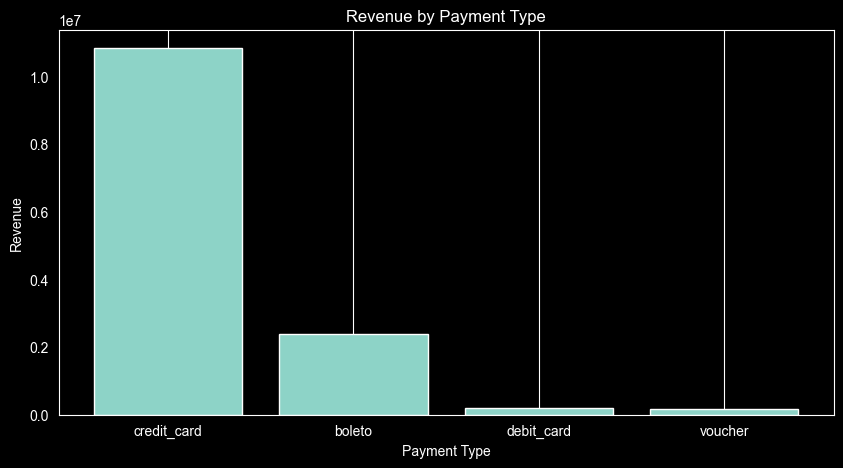

In [14]:
plt.figure(figsize=(10, 5))
plt.bar(payment_revenue["main_payment_type"], payment_revenue["revenue"])
plt.title("Revenue by Payment Type")
plt.xlabel("Payment Type")
plt.ylabel("Revenue")
plt.grid(axis="y")
plt.show()

Основная часть выручки приходится на оплату кредитной картой. Вторым по значимости способом оплаты является `boleto`, но его вклад значительно ниже. `debit_card` и `voucher` дают небольшую долю выручки.

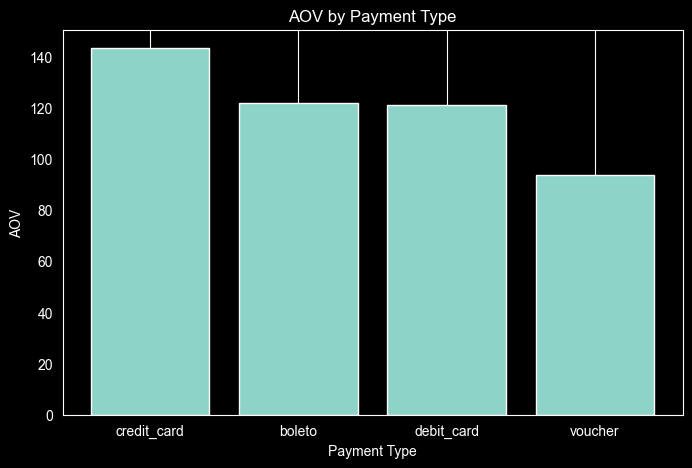

In [15]:
aov_by_payment = (orders_revenue.groupby("main_payment_type", as_index=False).agg(
        revenue=("revenue", "sum"),
        orders_count=("order_id", "nunique")
))
aov_by_payment["aov"] = aov_by_payment["revenue"] / aov_by_payment["orders_count"]
aov_by_payment = aov_by_payment.sort_values("aov", ascending=False)

plt.figure(figsize=(8, 5))
plt.bar(aov_by_payment["main_payment_type"], aov_by_payment["aov"])
plt.title("AOV by Payment Type")
plt.xlabel("Payment Type")
plt.ylabel("AOV")
plt.grid(axis="y")
plt.show()

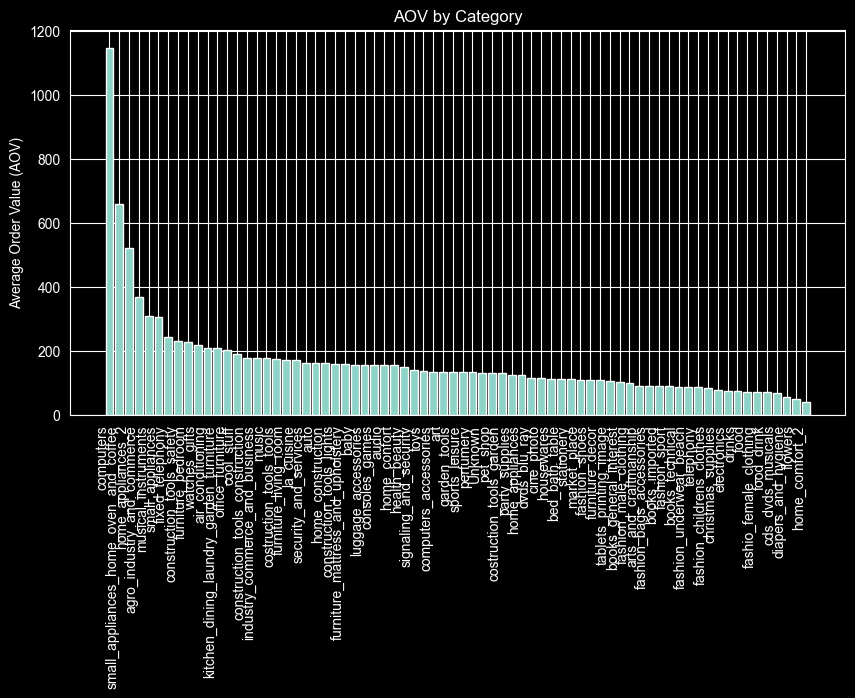

In [16]:
aov_by_category = (order_items_mart.groupby("product_category_name_english", as_index=False).agg(aov=("item_total", "mean")).sort_values("aov", ascending=False))
plt.figure(figsize=(10,5))
plt.bar(aov_by_category["product_category_name_english"], aov_by_category["aov"])
plt.xticks(rotation=90, ha="right")
plt.ylabel("Average Order Value (AOV)")
plt.title("AOV by Category")
plt.show()

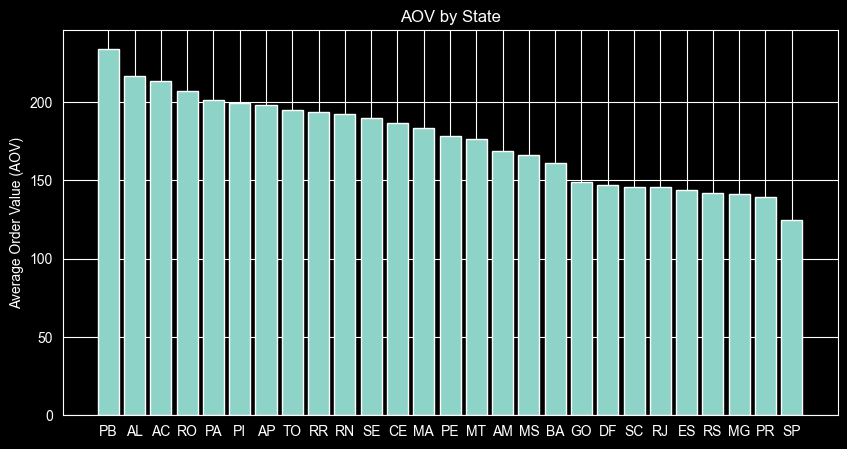

In [17]:
aov_by_state = (order_items_mart.groupby("customer_state", as_index=False).agg(aov=("item_total", "mean")).sort_values("aov", ascending=False))
plt.figure(figsize=(10,5))
plt.bar(aov_by_state["customer_state"], aov_by_state["aov"])
plt.ylabel("Average Order Value (AOV)")
plt.title("AOV by State")
plt.show()

In [18]:
order_items_mart.columns

Index(['order_id', 'order_item_id', 'product_id', 'seller_id',
       'shipping_limit_date', 'price', 'freight_value', 'item_total',
       'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'order_month', 'order_year', 'delivery_days', 'expected_delivery_days',
       'delay_days', 'is_late', 'exact_delay_days', 'delay_group',
       'expected_group', 'customer_unique_id', 'customer_zip_code_prefix',
       'customer_city', 'customer_state', 'product_category_name',
       'product_name_lenght', 'product_description_lenght',
       'product_photos_qty', 'product_weight_g', 'product_length_cm',
       'product_height_cm', 'product_width_cm',
       'product_category_name_english', 'seller_zip_code_prefix',
       'seller_city', 'seller_state', 'review_score', 'positive_review',
       'neutral_review', 'negative_review', 'payment_total', 'p

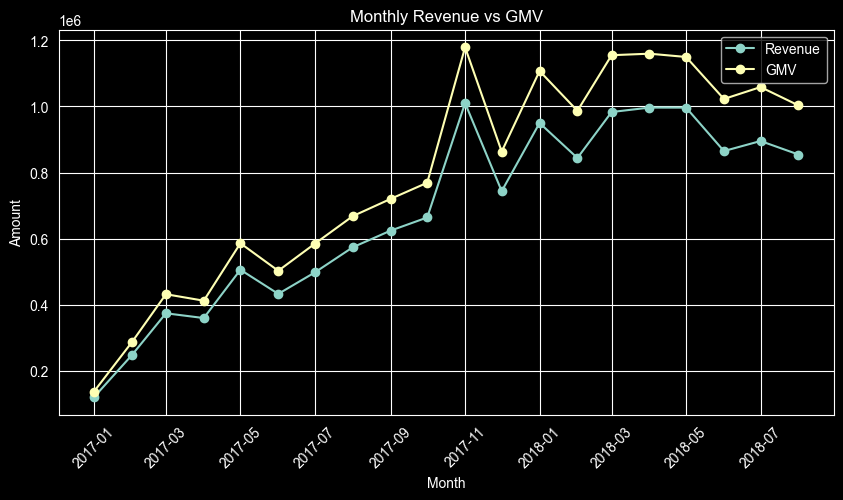

In [19]:
monthly_metrics = order_items_mart.groupby("order_month_date", as_index=False).agg(revenue=("price", "sum"), gmv=("item_total", "sum"))

monthly_metrics_clean = monthly_metrics[(monthly_metrics["order_month_date"] >= "2017-01-01") &(monthly_metrics["order_month_date"] <= "2018-08-01")]

plt.figure(figsize=(10,5))
plt.plot(monthly_metrics_clean["order_month_date"], monthly_metrics_clean["revenue"], marker="o", label="Revenue")
plt.plot(monthly_metrics_clean["order_month_date"], monthly_metrics_clean["gmv"], marker="o", label="GMV")
plt.title("Monthly Revenue vs GMV")
plt.xlabel("Month")
plt.ylabel("Amount")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.show()

GMV стабильно выше Revenue, так как включает стоимость доставки.

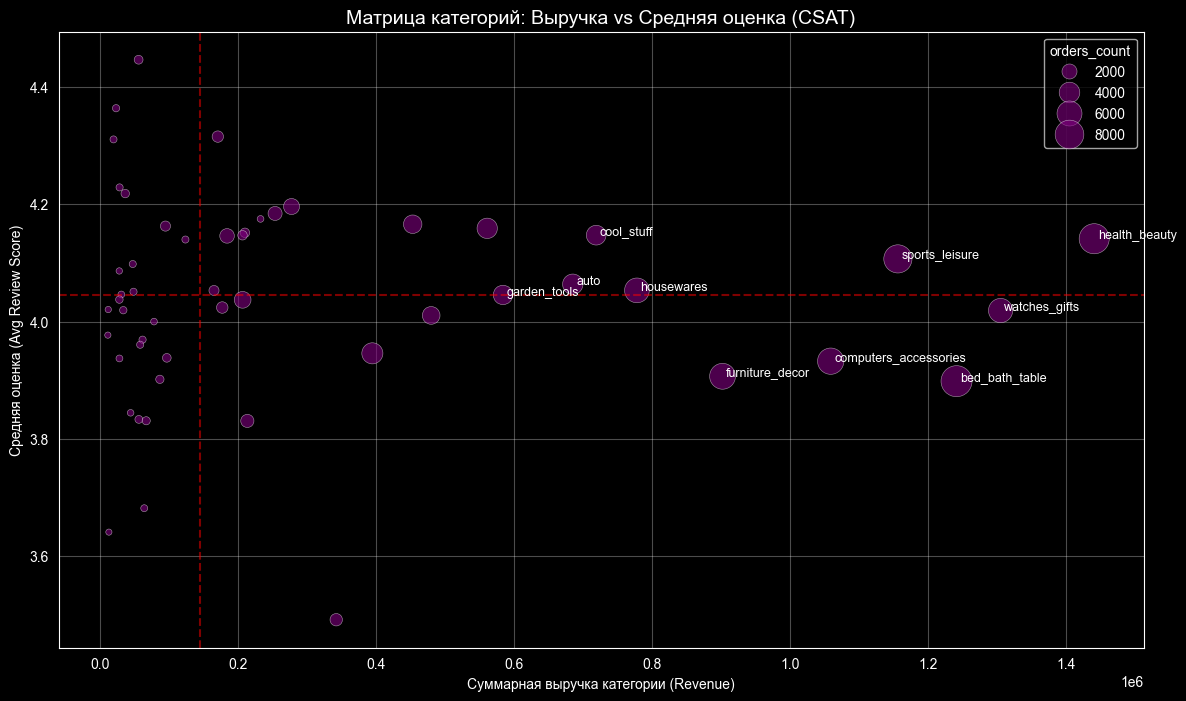

In [27]:
cat_analysis = order_items_mart.groupby('product_category_name_english', as_index=False).agg(
    revenue=('item_total', 'sum'),
    avg_review=('review_score', 'mean'),
    orders_count=('order_id', 'nunique')
)

cat_analysis = cat_analysis[cat_analysis['orders_count'] >= 100]

rev_median = cat_analysis['revenue'].median()
review_median = cat_analysis['avg_review'].median()

plt.figure(figsize=(14, 8))
sns.scatterplot(
    data=cat_analysis,
    x='revenue',
    y='avg_review',
    size='orders_count',
    sizes=(20, 500),
    alpha=0.6,
    color='purple'
)

plt.axvline(x=rev_median, color='red', linestyle='--', alpha=0.5)
plt.axhline(y=review_median, color='red', linestyle='--', alpha=0.5)

top_cats = cat_analysis.sort_values('revenue', ascending=False).head(10)
for i, row in top_cats.iterrows():
    plt.text(row['revenue'] + 5000, row['avg_review'], row['product_category_name_english'], fontsize=9)

plt.title('Матрица категорий: Выручка vs Средняя оценка (CSAT)', fontsize=14)
plt.xlabel('Суммарная выручка категории (Revenue)')
plt.ylabel('Средняя оценка (Avg Review Score)')
plt.grid(True, alpha=0.3)
plt.show()

### Продуктовые выводы по матрице категорий (Квадрант-анализ):
Разделение линий медиан позволяет наглядно разбить наши товарные категории на 4 ключевых бизнес-квадранта:

1. **Правый верхний («Звезды»):** Категории с высокой выручкой и отличными оценками клиентов (например, `health_beauty`). Это главные драйверы нашего маркетплейса. Маркетингу стоит распределять бюджет на их продвижение в первую очередь.
2. **Правый нижний («Проблемные гиганты»):** Категории генерируют огромный оборот, но клиенты систематически ставят им низкие оценки. Это критическая зона риска. Бизнесу нужно срочно провести аудит продавцов в этих категориях, проверить качество упаковки и логистику — здесь маркетплейс теряет лояльность на больших объемах.
3. **Левый верхний («Нишевые алмазы»):** Приносят пока относительно мало денег, но имеют идеальный рейтинг удовлетворённости. У этих ниш высочайший потенциал для масштабирования с помощью целевой рекламы и расширения ассортимента.
4. **Левый нижний («Аутсайдеры»):** Низкая выручка и плохой клиентский опыт. Категории, требующие жесткого пересмотра правил модерации или сокращения присутствия на платформе.